<h1 style="color: RGB(27, 169, 127); font-size: 50pt";>PAP 2.2 – Python-Auswertung</h1>

## Wichtige Funktionen für das PAP.

Alle in diesem Dokument geschriebenen Zeilen Code sind von mir eigenständig geschrieben. Für ein sauberes und struktiriertes Dokument wurde eine eigene Pythonlibary geschrieben, welche insbesondere ans PAP angepasst wurde. Dieses ist unter dem Namen "Papulator" auf meinem GitHub zu finden. Diese soll setig ausgearbeitet werden. Der Stand dieses Protokolls ist der 29.04.2026.
 
----

# Inhaltsverzeichnis zur Auswertung
* [Definition der Versuchsvariablen](#Definition-der-Versuchsvariablen)
* [Import aller genutzen Libaries](#Import-aller-genutzen-Libaries)
* [Auswertung der Aufgaben](#Auswertung-der-Aufgaben)
    * [Aufgabe 1](#Aufgabe-1)
    * [Aufgabe 2](#Aufgabe-2)
    * [Aufgabe 3](#Aufgabe-3)
    * [Aufgabe 4](#Aufgabe-4)

---
---

# Definition der Versuchsvariablen

Im Folgenden sind Versuchsvariablen definiert, die für einen besseren Workflow sorgen sollen. Diese werden zum exportieren und überschreiben von Dateien wichtig sein und ermöglichen es, diese Datei für jeden Versuch zu benutzen und lediglich die Variablen zu verändern. Es ist jedoch empfohlen eine Kopie der Forlage für jeden Versuch zu machen, damit dieses Dokument strukturiert bleibt.

Zudem sind wichtige Konstanten definiert, die immer wieder auftauchen.

In [112]:
experiment_number = "255"
experiment_name = "Versuchs_Name" 
task = "0z"
plt_save_folder = f"../img/plots/"

# Import aller genutzen Libaries

In [113]:
# Eigene Pythonlibary für das Pap
import Papulator as pap
from Papulator import Colors as c
from Papulator import const
from Papulator import Sympy_Symbols as sym

# Numpy für bessere Berechnungen
import numpy as np
from numpy import exp, sqrt, log, pi
from uncertainties import unumpy as unp

# Weiteres für bessere Rechnungen
import pylab as py

import math

# Berechnungen und Plotting
from scipy import odr
import scipy.optimize
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.stats import chi2
from scipy.stats import poisson
from scipy.signal import find_peaks
from scipy.signal import argrelextrema, argrelmin, argrelmax
from scipy.special import factorial
from scipy.integrate import quad

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.transforms as transforms

import astropy.units as u

# Zum Auslesen von Dateien und ähnlichem
import os
import os.path

import pandas as pd
import csv
import re

from io import StringIO

# Besseres Funktionen handling
import sympy as sp
from sympy import separatevars

<hr>
<hr>

# Auswertung der Aufgaben

<hr>

## Aufgabe 1

In [114]:
# Import txt Data
angle_T1, counts_T1 = np.loadtxt('data/T1.txt', dtype=str, unpack=True)
angle_T1 = np.char.replace(angle_T1, ',', '.').astype(float)
err_angle_T1 = 0.05 # deg
counts_T1 = np.char.replace(counts_T1, ',', '.').astype(float)
err_intensity_T1 = sqrt(counts_T1)

In [115]:
# linear regression
def linear(x,m,b):
    return m * x + b

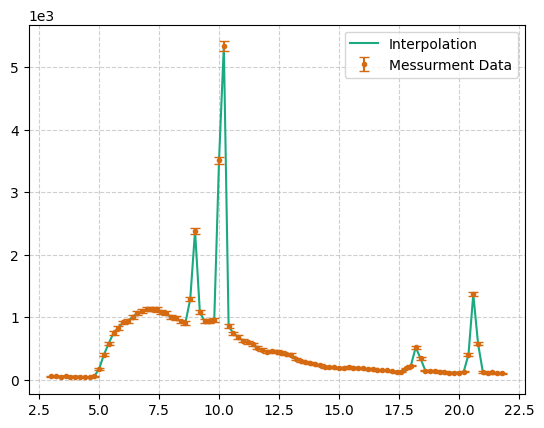

<Axes: >

In [116]:
plt.plot(
    angle_T1,
    counts_T1,
    label='Interpolation',
    )

plt.errorbar(
    angle_T1,
    counts_T1,
    err_intensity_T1,
    label='Messurment Data',
    marker = '.',
    ls = ' ',
    capsize=3.5
    )

pap.plot_me()

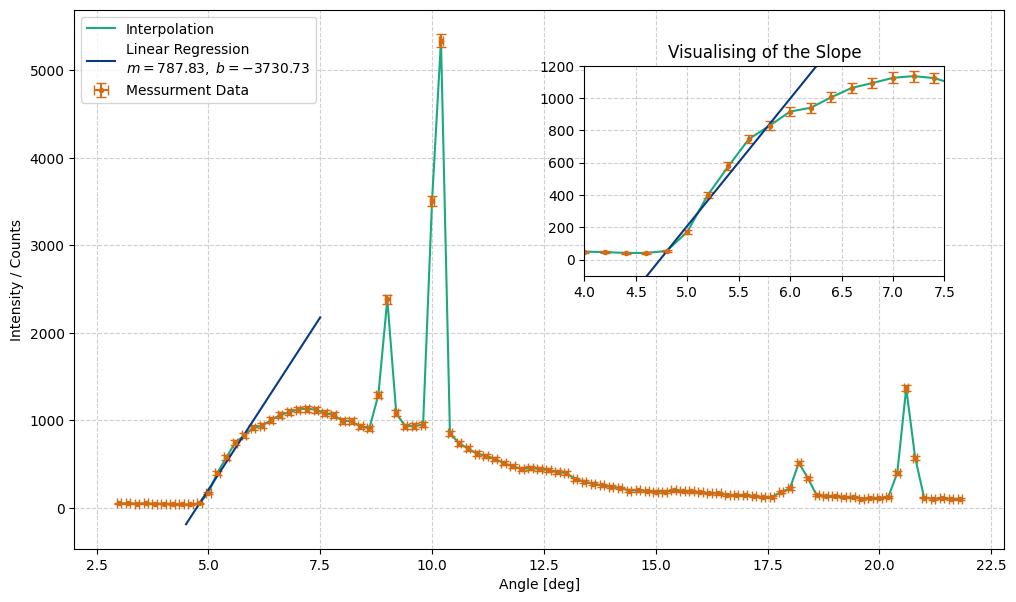

In [123]:
task = '1a'
plt.figure(figsize = (12,7))

# Default interpolation
plt.plot(
    angle_T1,
    counts_T1,
    label='Interpolation',
    )

# Messurment data
plt.errorbar(
    angle_T1,
    counts_T1,
    err_intensity_T1,
    err_angle_T1,
    label='Messurment Data',
    marker = '.',
    ls = ' ',
    capsize=3.5
    )

# Regression
# Range of linear regression
start, end = 9, 16
popt, pcov = curve_fit(linear, angle_T1[start:end], counts_T1[start:end], sigma=err_intensity_T1[start:end])

x = np.linspace(4.5, 7.5, 100)
plt.plot(
    x,
    linear(x, *popt),
    label = f'Linear Regression\n$m={popt[0]:.2f}, \\; b={popt[1]:.2f}$'
)

plt.legend(loc = 'upper left')
plt.xlabel('Angle [deg]')
plt.ylabel('Intensity / Counts')
# Small Window
a = plt.axes([.55, .50, .3, .3], facecolor = 'white')

plt.plot(
    angle_T1,
    counts_T1,
    label='Interpolation',
    )

# Messurment data
plt.errorbar(
    angle_T1,
    counts_T1,
    err_intensity_T1,
    label='Messurment Data',
    marker = '.',
    ls = ' ',
    capsize=3.5
    )

plt.plot(
    x,
    linear(x, *popt),
    label = f'Linear Regression\n$m={popt[0]:.2f}, \\; b={popt[1]:.2f}$'
)

plt.xlim(4, 7.5)
plt.ylim(-100, 1200)
plt.title('Visualising of the Slope')

plt.savefig(f'{plt_save_folder}hohle_spectrum_and_slope_{task}')
plt.show()

<hr>

## Aufgabe 2

<hr>

## Aufgabe 3

In [118]:
# Creating the Array for the voltages
steps = 15
U_B = np.zeros([steps])
start_voltage = 20 # kV
for i in range(steps):
    U_B[i] = start_voltage
    start_voltage = start_voltage + 1

U_B * u.kV

<Quantity [20., 21., 22., 23., 24., 25., 26., 27., 28., 29., 30., 31., 32.,
           33., 34.] kV>

In [119]:
# Cretaing the array for the counts for each foltage
counts_T3 = np.array([0.9, 1.05, 1.85, 23.15, 116.2, 321.6, 405.1, 573.1, 673.8, 769.2, 945.8, 1011.4, 1090.8, 1172.5, 1235.7])

print(f'Same amount of voltages and counts: {len(U_B) == len(counts_T3)}')

Same amount of voltages and counts: True


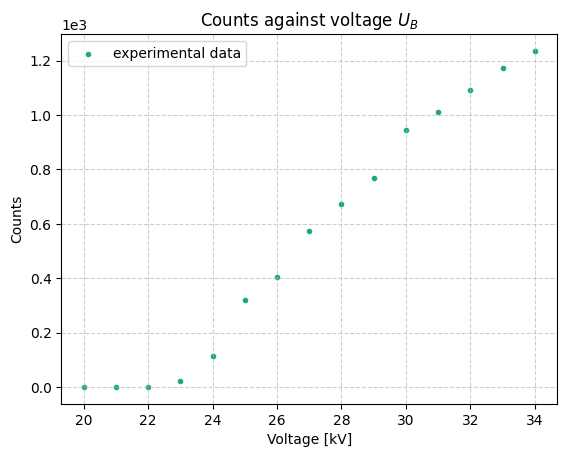

<Axes: title={'center': 'Counts against voltage $U_B$'}, xlabel='Voltage [kV]', ylabel='Counts'>

In [120]:
plt.scatter(
    U_B[0:len(counts_T3)],
    counts_T3,
    marker = '.',
    label='experimental data'
)

pap.plot_me('Counts against voltage $U_B$', 'Voltage [kV]', 'Counts')

<hr>

## Aufgabe 4